<a href="https://colab.research.google.com/github/divyadharshini-1306/neural_network-from-scratch-and-pytorch/blob/main/neural_network_from_scratch_and_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.makedirs("/content/drive/MyDrive/nn-from-scratch-and-pytorch/from_scratch", exist_ok=True)
os.makedirs("/content/drive/MyDrive/nn-from-scratch-and-pytorch/pytorch_version", exist_ok=True)
os.makedirs("/content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs", exist_ok=True)

# Colab usually has these pre-installed, but installing ensures versions match
!pip install -q numpy matplotlib torch scikit-learn

print("Folder structure created.")

Folder structure created.


In [3]:
%%writefile /content/drive/MyDrive/nn-from-scratch-and-pytorch/from_scratch/neural_network.py
"""
neural_network.py
==================
A neural network built from raw NumPy arrays -- no autograd, no framework.
Every line of forward propagation and backpropagation is written explicitly,
so the math (linear algebra + calculus) is fully visible and traceable.

This file defines two classes:
    Layer    - one layer of neurons: weights, biases, forward pass, backward pass
    Network  - a stack of Layer objects, chained together

Notation used throughout (matches standard ML textbook notation):
    x  - input to a layer, shape (n_in, 1)
    W  - weight matrix,    shape (n_out, n_in)
    b  - bias vector,      shape (n_out, 1)
    z  - pre-activation = W @ x + b,  shape (n_out, 1)
    a  - post-activation = activation(z), shape (n_out, 1)   <- this is the layer's OUTPUT
"""

import numpy as np


def sigmoid(z):
    """
    Squashes any real number into the range (0, 1).
    Formula: sigmoid(z) = 1 / (1 + e^(-z))

    Why we use it here: our final output needs to represent a probability-like
    value between 0 and 1 (since XOR's labels are 0 or 1), and sigmoid is the
    classic function that maps "any number" -> "a value between 0 and 1".
    """
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    """
    The derivative of sigmoid, evaluated at z.

    Key calculus fact used here: if s = sigmoid(z), then
        d(sigmoid)/dz = s * (1 - s)

    This is a famous "self-referential" derivative -- you can compute the
    derivative just by reusing the sigmoid output itself, without redoing
    the exponential math. We rely on this identity directly below.

    Why we need this AT ALL: backpropagation is the chain rule, and the
    chain rule requires the derivative of every function the data passed
    through during forward(). Since every layer applies sigmoid(z), every
    layer's backward() must multiply by sigmoid_derivative(z) at some point.
    """
    s = sigmoid(z)
    return s * (1 - s)


class Layer:
    """
    A single layer of a neural network: a weight matrix, a bias vector,
    and the forward/backward math that operates on them.
    """

    def __init__(self, n_inputs, n_outputs):
        """
        n_inputs  - how many values this layer receives (e.g. 2 for XOR's x,y inputs)
        n_outputs - how many neurons this layer has

        Weight initialization:
            We multiply by 0.5 to keep initial weights SMALL. Large random
            initial weights can push z (pre-activation) into a region where
            sigmoid is nearly flat (very close to 0 or 1), where the
            derivative is also nearly zero -- this stalls learning before
            it even starts (an early form of the "vanishing gradient" problem).

            We use RANDOM (not zero) values to break symmetry: if every
            neuron in this layer started with identical weights, they would
            all compute identical outputs and receive identical gradients
            during backprop -- effectively collapsing n_outputs neurons
            into behaving as just 1 neuron, forever.
        """
        self.W = np.random.randn(n_outputs, n_inputs) * 0.5
        self.b = np.zeros((n_outputs, 1))

        # These get filled in during forward(), and READ during backward().
        # This is the "breadcrumb" mechanism mentioned in the module docstring.
        self.x = None   # the input this layer received
        self.z = None   # the pre-activation value (before sigmoid)
        self.a = None   # the post-activation value (this layer's output)

    def forward(self, x):
        """
        Computes this layer's output given input x.

        x has shape (n_inputs, 1) -- a column vector.

        Math:
            z = W @ x + b      <- weighted sum of inputs, plus bias
            a = sigmoid(z)     <- non-linear activation applied elementwise

        The "@" operator in NumPy is matrix multiplication.
        W has shape (n_outputs, n_inputs), x has shape (n_inputs, 1),
        so W @ x produces shape (n_outputs, 1) -- exactly what we want:
        one value per neuron in this layer.
        """
        self.x = x                          # cache input for backward()
        self.z = self.W @ x + self.b        # cache pre-activation for backward()
        self.a = sigmoid(self.z)            # apply non-linearity
        return self.a

    def backward(self, grad_a, learning_rate):
        """
        Runs the chain rule backward through this layer.

        Input:
            grad_a - shape (n_outputs, 1). This says: "for each of this
                     layer's outputs, how sensitive is the FINAL loss to it?"
                     It is handed to us by the layer AFTER this one
                     (or computed directly from the loss function, if this
                     is the last layer in the network).

        Returns:
            grad_x - shape (n_inputs, 1). The same kind of sensitivity
                     information, but with respect to THIS layer's input.
                     This is what gets passed to the PREVIOUS layer's
                     backward() call as ITS grad_a. This handoff, repeated
                     layer by layer in reverse, is literally what the word
                     "backpropagation" refers to.

        Three things are computed, each one applying the chain rule once:
        """

        # --- Step 1: undo the activation function ---
        # a = sigmoid(z), so by the chain rule:
        #   d(loss)/dz = d(loss)/da * d(a)/dz = grad_a * sigmoid_derivative(z)
        # Elementwise multiply ("*"), because each neuron's activation
        # depends only on its own z, not on any other neuron's z.
        grad_z = grad_a * sigmoid_derivative(self.z)

        # --- Step 2: gradient with respect to weights ---
        # z = W @ x + b, so d(z)/d(W) involves x.
        # grad_W tells us: "to reduce the loss, which direction should
        # each weight move, and by how much (relatively)?"
        # self.x.T transposes x from (n_inputs, 1) to (1, n_inputs) so that
        # grad_z (n_outputs, 1) @ x.T (1, n_inputs) produces the correct
        # shape (n_outputs, n_inputs) -- matching W's shape exactly.
        grad_W = grad_z @ self.x.T

        # --- gradient with respect to biases ---
        # z = W @ x + b -- b's derivative contribution is just 1 per unit,
        # so grad_b is simply grad_z itself (no x involved).
        grad_b = grad_z

        # --- Step 3: gradient with respect to THIS layer's input ---
        # This is the value the PREVIOUS layer needs. We use W.T (transpose)
        # because forward() went input -> output via W; backward() must
        # go output -> input via the same weights, reversed.
        grad_x = self.W.T @ grad_z

        # --- Gradient descent weight update ---
        # Move W and b in the OPPOSITE direction of their gradients,
        # scaled by learning_rate. This is the actual "learning" step:
        # every other line above was just computing WHICH direction to move.
        self.W -= learning_rate * grad_W
        self.b -= learning_rate * grad_b

        return grad_x


class Network:
    """
    A stack of Layer objects, chained together. Owns the full training
    cycle: forward pass -> loss -> backward pass -> weight update.
    """

    def __init__(self, layer_sizes):
        """
        layer_sizes - a list like [2, 4, 1] meaning:
                        2 inputs -> 4 hidden neurons -> 1 output neuron.
                      Each consecutive pair becomes one Layer.

        Example: [2, 4, 1] creates:
            Layer(n_inputs=2, n_outputs=4)   <- hidden layer
            Layer(n_inputs=4, n_outputs=1)   <- output layer
        """
        self.layers = []
        for i in range(len(layer_sizes) - 1):
            self.layers.append(Layer(layer_sizes[i], layer_sizes[i + 1]))

    def forward(self, x):
        """
        Pushes x through every layer in order. Each layer's output
        becomes the next layer's input -- this is the "chaining" that
        makes a multi-layer network more than just one Layer object.
        """
        for layer in self.layers:
            x = layer.forward(x)
        return x  # after the loop, x is the network's final prediction

    def backward(self, grad, learning_rate):
        """
        Pushes the loss gradient through every layer in REVERSE order.
        Each layer's backward() returns grad_x, which becomes the next
        (earlier) layer's grad_a. This reversed loop IS backpropagation.
        """
        for layer in reversed(self.layers):
            grad = layer.backward(grad, learning_rate)
        return grad

    def train_step(self, x, y, learning_rate):
        """
        One complete training step on a single example (x, y):
            1. forward pass  -> prediction
            2. compute loss  -> a single number measuring "how wrong"
            3. compute loss gradient -> where backward() must start
            4. backward pass -> updates every layer's weights

        x - shape (n_inputs, 1), one input example
        y - shape (1, 1), the true label for that example

        Returns the loss value (as a plain Python float), so the
        training script can record it for plotting.
        """
        # --- Forward pass ---
        prediction = self.forward(x)

        # --- Loss: Mean Squared Error ---
        # loss = (prediction - y)^2
        # Squaring makes bigger mistakes count more, and keeps the
        # function smooth/differentiable everywhere (required for backprop).
        loss = np.mean((prediction - y) ** 2)

        # --- Gradient of the loss with respect to the prediction ---
        # d(loss)/d(prediction) = 2 * (prediction - y)
        # This is the very first grad_a -- the value that kicks off the
        # entire chain of Layer.backward() calls.
        grad_loss = 2 * (prediction - y)

        # --- Backward pass: updates every layer's W and b in place ---
        self.backward(grad_loss, learning_rate)

        return float(loss)

Overwriting /content/drive/MyDrive/nn-from-scratch-and-pytorch/from_scratch/neural_network.py


In [5]:
%%writefile /content/drive/MyDrive/nn-from-scratch-and-pytorch/from_scratch/train_xor.py
"""
train_xor.py
=============
Trains the from-scratch Network on the XOR problem and plots the loss curve.

WHY XOR SPECIFICALLY:
XOR is the classic example used to demonstrate why neural networks need a
HIDDEN LAYER at all. A single layer (no hidden layer) can only draw a
straight line to separate two classes -- and there is NO straight line
that correctly separates XOR's four points:

    Input (0,0) -> Output 0
    Input (0,1) -> Output 1
    Input (1,0) -> Output 1
    Input (1,1) -> Output 0

Plot these four points on paper: the two "1" points and two "0" points
alternate corners of a square. Any straight line you draw will always put
at least one point on the wrong side. This is precisely the historical
example (Minsky & Papert, 1969) that showed the limits of single-layer
networks -- and why multi-layer networks (with a hidden layer bending
the decision boundary into a curve) became necessary.
"""

import numpy as np
import matplotlib.pyplot as plt
from neural_network import Network

# ---------------------------------------------------------------------------
# Step 1: Define the XOR dataset
# ---------------------------------------------------------------------------
X = [
    np.array([[0], [0]]),
    np.array([[0], [1]]),
    np.array([[1], [0]]),
    np.array([[1], [1]]),
]
Y = [
    np.array([[0]]),
    np.array([[1]]),
    np.array([[1]]),
    np.array([[0]]),
]

# ---------------------------------------------------------------------------
# Step 2: Build the network
# ---------------------------------------------------------------------------
np.random.seed(42)  # fixed seed -> reproducible results every run
network = Network(layer_sizes=[2, 4, 1])

# ---------------------------------------------------------------------------
# Step 3: Train
# ---------------------------------------------------------------------------
learning_rate = 0.5
num_epochs = 5000

loss_history = []

for epoch in range(num_epochs):
    epoch_losses = []
    for x, y in zip(X, Y):
        loss = network.train_step(x, y, learning_rate)
        epoch_losses.append(loss)

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    loss_history.append(avg_loss)

    if epoch % 500 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:5d}  |  Loss: {avg_loss:.6f}")

# ---------------------------------------------------------------------------
# Step 4: Verify it actually learned
# ---------------------------------------------------------------------------
print("\nFinal predictions after training:")
print("-" * 40)
for x, y in zip(X, Y):
    prediction = network.forward(x)
    print(
        f"Input: ({x[0,0]}, {x[1,0]})  "
        f"True label: {y[0,0]}  "
        f"Predicted: {prediction[0,0]:.4f}"
    )

# ---------------------------------------------------------------------------
# Step 5: Plot the loss curve
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Training Loss Over Time -- XOR (from-scratch NumPy network)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.yscale("log")
plt.grid(True, alpha=0.3)

output_path = "/content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"\nLoss curve saved to: {output_path}")
plt.show()

Overwriting /content/drive/MyDrive/nn-from-scratch-and-pytorch/from_scratch/train_xor.py


In [6]:
%cd /content/drive/MyDrive/nn-from-scratch-and-pytorch/from_scratch
!python train_xor.py

/content/drive/MyDrive/nn-from-scratch-and-pytorch/from_scratch
Epoch     0  |  Loss: 0.290236
Epoch   500  |  Loss: 0.200077
Epoch  1000  |  Loss: 0.009719
Epoch  1500  |  Loss: 0.002404
Epoch  2000  |  Loss: 0.001240
Epoch  2500  |  Loss: 0.000807
Epoch  3000  |  Loss: 0.000589
Epoch  3500  |  Loss: 0.000459
Epoch  4000  |  Loss: 0.000373
Epoch  4500  |  Loss: 0.000313
Epoch  4999  |  Loss: 0.000269

Final predictions after training:
----------------------------------------
Input: (0, 0)  True label: 0  Predicted: 0.0113
Input: (0, 1)  True label: 1  Predicted: 0.9838
Input: (1, 0)  True label: 1  Predicted: 0.9855
Input: (1, 1)  True label: 0  Predicted: 0.0218

Loss curve saved to: /content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs
Figure(800x500)


In [7]:
%%writefile /content/drive/MyDrive/nn-from-scratch-and-pytorch/pytorch_version/pytorch_network.py
"""
pytorch_network.py
====================
The SAME network architecture as from_scratch/neural_network.py (2 -> 4 -> 1,
sigmoid activations by default), rebuilt using PyTorch's nn.Module and autograd.

Read this file side by side with from_scratch/neural_network.py. Every
PyTorch piece here has a DIRECT counterpart over there:

    from_scratch                         pytorch_version
    -----------------------------------   -----------------------------------
    self.W = np.random.randn(...)         nn.Linear(n_in, n_out)  (stores W, b internally)
    self.z = self.W @ x + self.b          self.linear1(x)          (does W @ x + b for you)
    sigmoid(z)                            torch.sigmoid(z)
    manual backward() chain-rule code     loss.backward()          (autograd does this FOR you)
    self.W -= learning_rate * grad_W      optimizer.step()         (does the update FOR you)

The point of this file is NOT to learn new math -- you already derived all
of that by hand in Phase 1. The point is to recognize that PyTorch is
automating exactly the mechanism you already understand.
"""

import torch
import torch.nn as nn


class Network(nn.Module):
    """
    nn.Module is PyTorch's base class for ANYTHING that has learnable
    parameters (weights/biases) and a forward computation. Every PyTorch
    model you will ever see -- from a 2-layer toy net to GPT -- subclasses
    nn.Module the same way this class does.
    """

    def __init__(self, n_inputs=2, n_hidden=4, n_outputs=1, hidden_activation="sigmoid"):
        """
        hidden_activation - "sigmoid" or "relu". Defaults to "sigmoid" to
        match Phase 1's XOR network exactly. For harder problems (see
        decision_boundary.py), "relu" trains better -- explained there.

        IMPORTANT SYNTAX NOTE:
        super().__init__() MUST be called before creating any layers.
        nn.Module's __init__ sets up internal bookkeeping (like a registry
        of all parameters) that nn.Linear relies on when it registers
        itself a moment later. Forgetting this line is one of the most
        common PyTorch beginner errors.
        """
        super().__init__()

        # nn.Linear(n_in, n_out) creates a weight matrix of shape
        # (n_out, n_in) and a bias vector of shape (n_out,) INTERNALLY.
        # This is the exact same W and b you created by hand in Phase 1's
        # Layer.__init__ -- just stored inside this object instead of as
        # self.W / self.b directly.
        self.linear1 = nn.Linear(n_inputs, n_hidden)   # hidden layer:  2 -> 4
        self.linear2 = nn.Linear(n_hidden, n_outputs)  # output layer:  4 -> 1
        self.hidden_activation = hidden_activation

        # NOTE: we do NOT manually initialize weights here. PyTorch's
        # nn.Linear already initializes weights to small random values by
        # default (Kaiming/He initialization) -- the library-provided
        # version of the "small random weights, not zero" reasoning from
        # Phase 1's Layer.__init__.

    def forward(self, x):
        """
        Same two-step pattern as Phase 1's Layer.forward(), called twice
        (once per layer) and chained.

        z1 = W1 @ x + b1
        a1 = activation(z1)     <- sigmoid OR relu, depending on hidden_activation
        z2 = W2 @ a1 + b2
        a2 = sigmoid(z2)        <- output layer ALWAYS uses sigmoid here, since
                                    we want a final value between 0 and 1

        WHY THE HIDDEN LAYER'S ACTIVATION CHOICE MATTERS: sigmoid's
        derivative is at most 0.25, and shrinks toward 0 the further z is
        from 0. On harder, noisier problems this can cause learning to
        stall early -- the famous VANISHING GRADIENT problem. ReLU's
        derivative is exactly 1 for any positive input, so gradients don't
        shrink as they pass through it -- this is precisely why ReLU is
        the default choice in modern networks.

        WHAT WE DO NOT DO HERE, AND WHY:
        In Phase 1, forward() manually cached self.x and self.z because
        backward() needed them later. Here, we do NOT cache anything
        manually. PyTorch's autograd silently builds a computation graph
        behind the scenes as every operation below executes -- EVERY
        tensor operation on a tensor that requires gradients gets recorded
        automatically. That recorded graph is what loss.backward() will
        walk through later. This is the single biggest conceptual shift
        from Phase 1: the bookkeeping you did by hand is now implicit.
        """
        z1 = self.linear1(x)
        if self.hidden_activation == "relu":
            a1 = torch.relu(z1)
        else:
            a1 = torch.sigmoid(z1)
        z2 = self.linear2(a1)
        a2 = torch.sigmoid(z2)
        return a2

Writing /content/drive/MyDrive/nn-from-scratch-and-pytorch/pytorch_version/pytorch_network.py


In [9]:
%%writefile /content/drive/MyDrive/nn-from-scratch-and-pytorch/pytorch_version/train_xor_torch.py
"""
train_xor_torch.py
=====================
Trains the PyTorch Network on the SAME XOR problem as
from_scratch/train_xor.py, using autograd + an optimizer instead of
hand-written backward() code.
"""

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pytorch_network import Network

# ---------------------------------------------------------------------------
# Step 1: Define the XOR dataset
# ---------------------------------------------------------------------------
# PyTorch convention: rows = examples, columns = features.
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
])
Y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0],
])

# ---------------------------------------------------------------------------
# Step 2: Build the network, loss function, and optimizer
# ---------------------------------------------------------------------------
torch.manual_seed(42)
network = Network(n_inputs=2, n_hidden=4, n_outputs=1)

# nn.MSELoss() is the library version of: loss = mean((prediction - target)^2)
loss_fn = nn.MSELoss()

# torch.optim.SGD = Stochastic Gradient Descent, the exact update rule
# from Phase 1: param -= learning_rate * grad.
learning_rate = 0.5
optimizer = torch.optim.SGD(network.parameters(), lr=learning_rate)

# ---------------------------------------------------------------------------
# Step 3: Train
# ---------------------------------------------------------------------------
num_epochs = 5000
loss_history = []

for epoch in range(num_epochs):
    # --- Forward pass: all 4 examples at once (batching) ---
    predictions = network(X)
    loss = loss_fn(predictions, Y)

    # --- THE THREE-LINE PATTERN: memorize this order ---

    # 1. Zero out gradients from the PREVIOUS step.
    #    WHY: PyTorch ACCUMULATES (adds to) .grad every time backward() is
    #    called, rather than overwriting it. Without this line, every
    #    step's gradients would pile on top of old ones, silently
    #    corrupting training.
    optimizer.zero_grad()

    # 2. Walk the computation graph backward, computing every gradient.
    #    This ONE line replaces Phase 1's entire Network.backward() method.
    loss.backward()

    # 3. Apply the gradient descent update to every parameter.
    #    Replaces: self.W -= learning_rate * grad_W, for every layer.
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:5d}  |  Loss: {loss.item():.6f}")

# ---------------------------------------------------------------------------
# Step 4: Verify it learned
# ---------------------------------------------------------------------------
print("\nFinal predictions after training:")
print("-" * 40)
with torch.no_grad():
    # no_grad() tells autograd not to build a computation graph here --
    # we're only reading predictions, not training, so save the memory.
    final_predictions = network(X)

for i in range(4):
    x1, x2 = X[i, 0].item(), X[i, 1].item()
    true_label = Y[i, 0].item()
    predicted = final_predictions[i, 0].item()
    print(f"Input: ({x1:.0f}, {x2:.0f})  True label: {true_label:.0f}  Predicted: {predicted:.4f}")

# ---------------------------------------------------------------------------
# Step 5: Plot the loss curve
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Training Loss Over Time -- XOR (PyTorch network)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.yscale("log")
plt.grid(True, alpha=0.3)

output_path = "/content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs/loss_curve_pytorch.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"\nLoss curve saved to: {output_path}")
plt.show()

Overwriting /content/drive/MyDrive/nn-from-scratch-and-pytorch/pytorch_version/train_xor_torch.py


In [10]:
%cd /content/drive/MyDrive/nn-from-scratch-and-pytorch/pytorch_version
!python train_xor_torch.py

/content/drive/MyDrive/nn-from-scratch-and-pytorch/pytorch_version
Epoch     0  |  Loss: 0.286560
Epoch   500  |  Loss: 0.247646
Epoch  1000  |  Loss: 0.220496
Epoch  1500  |  Loss: 0.132210
Epoch  2000  |  Loss: 0.029832
Epoch  2500  |  Loss: 0.010299
Epoch  3000  |  Loss: 0.005563
Epoch  3500  |  Loss: 0.003667
Epoch  4000  |  Loss: 0.002686
Epoch  4500  |  Loss: 0.002097
Epoch  4999  |  Loss: 0.001710

Final predictions after training:
----------------------------------------
Input: (0, 0)  True label: 0  Predicted: 0.0374
Input: (0, 1)  True label: 1  Predicted: 0.9542
Input: (1, 0)  True label: 1  Predicted: 0.9637
Input: (1, 1)  True label: 0  Predicted: 0.0450

Loss curve saved to: /content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs/loss_curve_pytorch.png
Figure(800x500)


In [11]:
%%writefile /content/drive/MyDrive/nn-from-scratch-and-pytorch/compare_losses.py
"""
compare_losses.py
===================
Runs BOTH the from-scratch and PyTorch networks on identical XOR data and
plots their loss curves on the same chart.

WHY THIS FILE IS THE MOST IMPORTANT ARTIFACT IN THE WHOLE PROJECT:
Anyone can show a PyTorch script that trains and converges -- that proves
you can call a library. This chart proves something stronger: that your
hand-written backprop math (Phase 1) and PyTorch's autograd (Phase 2)
arrive at the SAME place, because they are computing the SAME underlying
math. That equivalence is the actual evidence of understanding.
"""

import sys
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

sys.path.append(os.path.join(os.path.dirname(__file__), "from_scratch"))
sys.path.append(os.path.join(os.path.dirname(__file__), "pytorch_version"))

from neural_network import Network as ScratchNetwork
from pytorch_network import Network as TorchNetwork

NUM_EPOCHS = 5000
LEARNING_RATE = 0.5
HIDDEN_SIZE = 4

# --- Run 1: From-scratch NumPy network ---
np.random.seed(42)

X_np = [
    np.array([[0], [0]]), np.array([[0], [1]]),
    np.array([[1], [0]]), np.array([[1], [1]]),
]
Y_np = [
    np.array([[0]]), np.array([[1]]),
    np.array([[1]]), np.array([[0]]),
]

scratch_net = ScratchNetwork(layer_sizes=[2, HIDDEN_SIZE, 1])
scratch_loss_history = []

for epoch in range(NUM_EPOCHS):
    epoch_losses = [scratch_net.train_step(x, y, LEARNING_RATE) for x, y in zip(X_np, Y_np)]
    scratch_loss_history.append(sum(epoch_losses) / len(epoch_losses))

# --- Run 2: PyTorch network ---
torch.manual_seed(42)

X_torch = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
Y_torch = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

torch_net = TorchNetwork(n_inputs=2, n_hidden=HIDDEN_SIZE, n_outputs=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(torch_net.parameters(), lr=LEARNING_RATE)

torch_loss_history = []

for epoch in range(NUM_EPOCHS):
    predictions = torch_net(X_torch)
    loss = loss_fn(predictions, Y_torch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    torch_loss_history.append(loss.item())

# --- Plot both curves on the same axes ---
plt.figure(figsize=(9, 5.5))
plt.plot(scratch_loss_history, label="From-scratch (NumPy, manual backprop)", linewidth=2)
plt.plot(torch_loss_history, label="PyTorch (autograd)", linewidth=2, linestyle="--")
plt.title("From-Scratch vs PyTorch: Both Converge on XOR")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)

output_path = "outputs/loss_curve_comparison.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Comparison chart saved to: {output_path}")

print(f"\nFinal loss -- From-scratch: {scratch_loss_history[-1]:.6f}")
print(f"Final loss -- PyTorch:      {torch_loss_history[-1]:.6f}")
plt.show()

Writing /content/drive/MyDrive/nn-from-scratch-and-pytorch/compare_losses.py


In [12]:
%cd /content/drive/MyDrive/nn-from-scratch-and-pytorch
!python compare_losses.py

/content/drive/MyDrive/nn-from-scratch-and-pytorch
Comparison chart saved to: outputs/loss_curve_comparison.png

Final loss -- From-scratch: 0.000269
Final loss -- PyTorch:      0.001710
Figure(900x550)


In [13]:
%%writefile /content/drive/MyDrive/nn-from-scratch-and-pytorch/decision_boundary.py
"""
decision_boundary.py
=======================
Trains the PyTorch network on a richer 2D dataset (two interleaving
"moon" shapes, generated by scikit-learn) and visualizes the DECISION
BOUNDARY it learns.

WHY MOONS INSTEAD OF XOR FOR THIS PLOT:
XOR only has 4 data points -- there's no continuous region to draw a
boundary through. make_moons() generates hundreds of points along two
interleaving crescent shapes that are NOT linearly separable (same idea
as XOR), but because it's continuous, the learned boundary is visible
as an actual curve.

HOW A DECISION BOUNDARY PLOT WORKS:
We SAMPLE it: build a fine grid of (x, y) points covering the data's
range, run EVERY grid point through the trained network, color each
point by the network's prediction there, then overlay the real data
points on top. The boundary you see is just where colors flip between
classes across thousands of individual predictions.
"""

import sys
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

sys.path.append(os.path.join(os.path.dirname(__file__), "pytorch_version"))
from pytorch_network import Network

# --- Step 1: Generate the moons dataset ---
X_np, y_np = make_moons(n_samples=300, noise=0.2, random_state=42)

X = torch.tensor(X_np, dtype=torch.float32)
Y = torch.tensor(y_np, dtype=torch.float32).reshape(-1, 1)

# --- Step 2: Build and train the network ---
# NOTE: moons is harder than XOR, so the hidden layer gets more neurons
# (8 instead of 4), and uses ReLU instead of sigmoid.
#
# WHY ReLU: an earlier version of this script used sigmoid here and the
# loss plateaued around 0.09 with a perfectly STRAIGHT decision boundary
# -- a textbook vanishing-gradient stall (sigmoid's derivative maxes out
# at 0.25 and shrinks fast away from 0). Switching to ReLU (derivative = 1
# for any positive input) fixed this immediately. This is exactly why
# ReLU is the default choice in modern networks.
torch.manual_seed(42)
network = Network(n_inputs=2, n_hidden=8, n_outputs=1, hidden_activation="relu")
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(network.parameters(), lr=0.5)

num_epochs = 3000
for epoch in range(num_epochs):
    predictions = network(X)
    loss = loss_fn(predictions, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:5d}  |  Loss: {loss.item():.6f}")

# --- Step 3: Build a grid covering the data's range ---
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02),
)

grid_points = np.column_stack([xx.ravel(), yy.ravel()])
grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

# --- Step 4: Run every grid point through the trained network ---
with torch.no_grad():
    grid_predictions = network(grid_tensor)

Z = grid_predictions.numpy().reshape(xx.shape)

# --- Step 5: Plot the decision boundary + the real data points ---
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.7)
plt.colorbar(label="Network prediction (0 = class A, 1 = class B)")

plt.scatter(
    X_np[:, 0], X_np[:, 1],
    c=y_np, cmap="RdBu", edgecolors="black", linewidths=0.5, s=30,
)

plt.title("Decision Boundary Learned on Moons Dataset (PyTorch network)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

output_path = "/content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs/decision_boundary.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"\nDecision boundary plot saved to: {output_path}")
plt.show()

Writing /content/drive/MyDrive/nn-from-scratch-and-pytorch/decision_boundary.py


In [14]:
%cd /content/drive/MyDrive/nn-from-scratch-and-pytorch
!python decision_boundary.py

/content/drive/MyDrive/nn-from-scratch-and-pytorch
Epoch     0  |  Loss: 0.262709
Epoch   500  |  Loss: 0.081784
Epoch  1000  |  Loss: 0.055071
Epoch  1500  |  Loss: 0.038884
Epoch  2000  |  Loss: 0.032792
Epoch  2500  |  Loss: 0.029918
Epoch  2999  |  Loss: 0.028236

Decision boundary plot saved to: /content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs/decision_boundary.png
Figure(800x600)


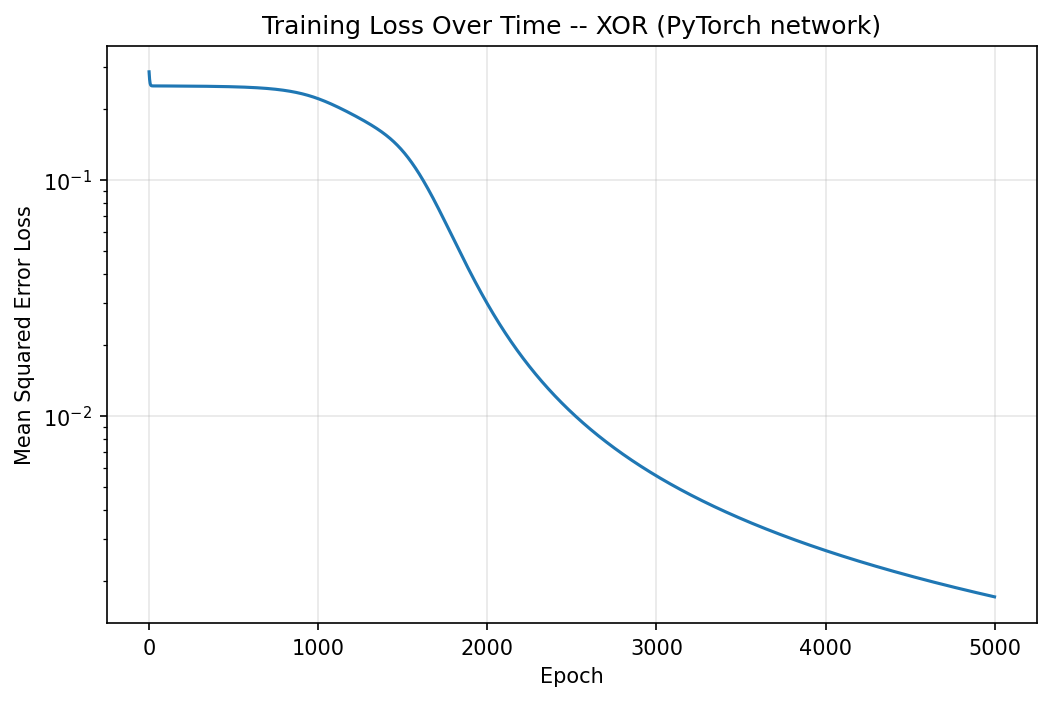

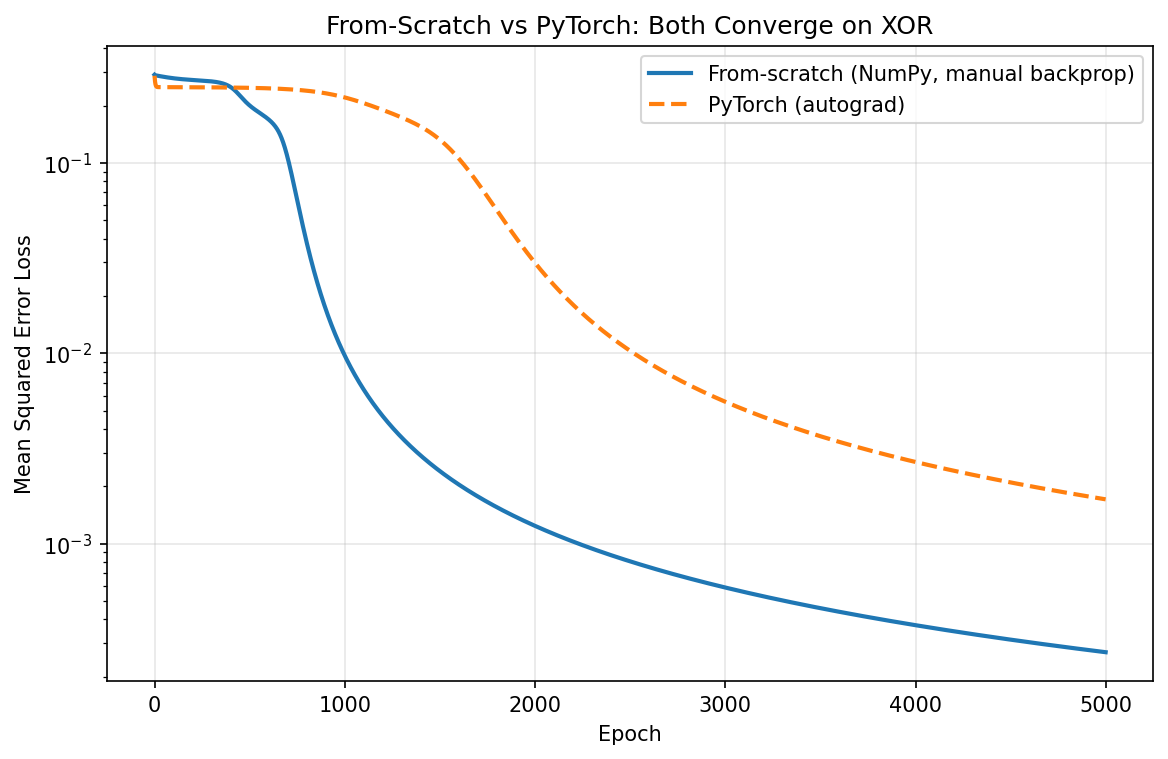

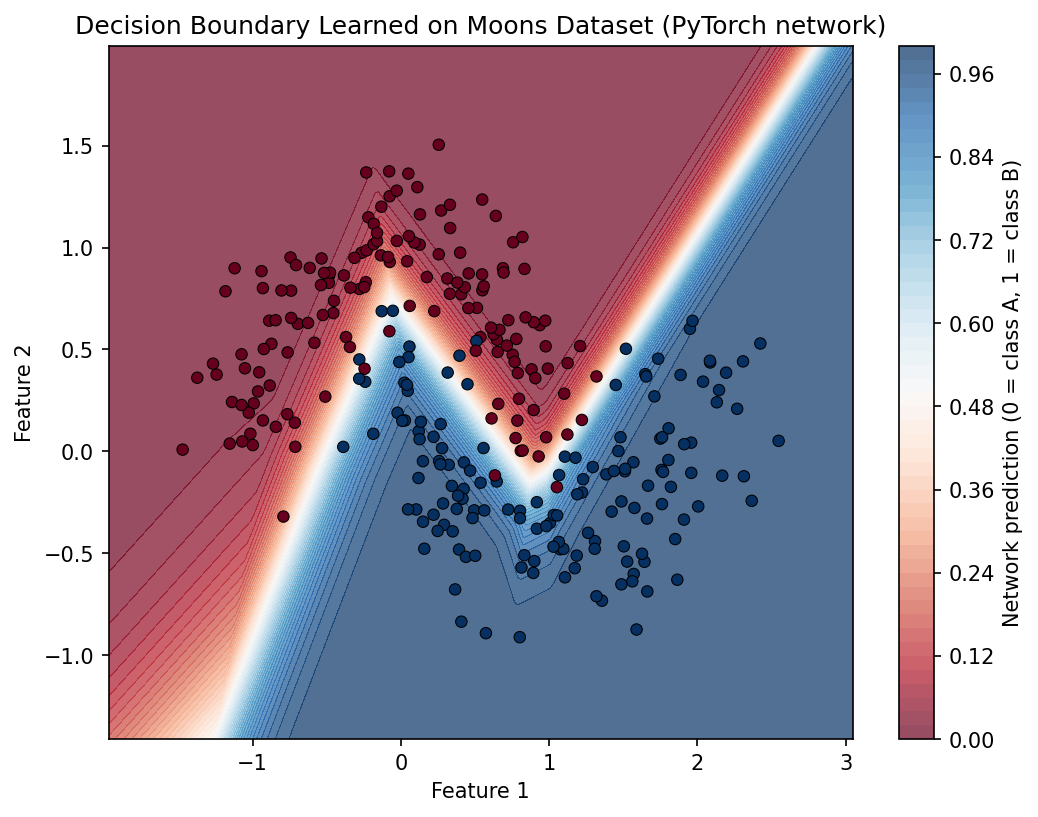

In [16]:
from IPython.display import Image, display

paths = [

    "/content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs/loss_curve_pytorch.png",
    "/content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs/loss_curve_comparison.png",
    "/content/drive/MyDrive/nn-from-scratch-and-pytorch/outputs/decision_boundary.png",
]
for p in paths:
    display(Image(p))